In [1]:
script = False
cluster = False

In [2]:
# general
import numpy as np
from numpy.ma import masked_array
import pandas as pd
import random
import os
import gc

# images & plotting
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from astropy.table import Table

# pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# albumentations transformations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# loading bar
if not cluster:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as plticker
    plt.style.use('dark_background')

In [3]:
class Dataset(Dataset):
    """
    PyTorch dataset of images and data
    Args:
        * images {(N, channels, pix, pix) array}: images for dataset
        * data {pandas dataframe}: data for images
        * resize: composed albumentations augmentation to resize images
                  and masks to correct size (96, 96) & tensor
    Returns: Pytorch dataset
    """

    def __init__(self, images, data, resize=None):
        super().__init__()
        self.images = images
        self.data = data
        self.resize = resize

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # get image
        image = self.normalize(img)
        data_point = self.data.iloc[idx].to_dict()  # get data

        # transpose to appropriate dimensions
        image = image.transpose(1, 2, 0)  # (pix, pix, channels)

        # resizing transformation
        if self.resize is not None:
            resized = self.resize(image=image)
            image = resized['image']
        
        # return item
        return {'image': image, 'img': img, 'data': data_point}

    def normalize(self, image):
        """
        Normalize image between 0 and 1 using min and max
        Args:
        * image: (3, pix, pix) numpy array
        Returns: normalized image in original size
        """
        normed = np.empty(image.shape)  # break
        MIN = np.min(image)
        MAX = np.max(image)
        for band in range(3):
            flat = image[band].flatten(order='C')
            for i in range(len(flat)):
                flat[i] = (flat[i]-MIN)/(MAX-MIN)

            normed[band] = np.reshape(flat, image[0].shape, order='C')

        return normed

In [4]:
def make_graphs(image, pred_label, coadd_id):
    loc = plticker.MultipleLocator(base=3.75)
    fig, ax = plt.subplots(figsize=(8, 4), ncols=2)

    rgb = make_lupton_rgb(image[2], image[1], image[0], Q=11., stretch=40.)
    ax[0].set_title('Image')
    ax[0].axis('off')
    ax[0].imshow(rgb, aspect='equal')
    
    # predicted label
    ax[1].set_title('Predicted Label')
    ax[1].imshow(pred_label[0, :, :], interpolation='nearest', cmap='magma')  # source
    ax[1].imshow(pred_label[1, :, :], alpha=0.5, interpolation='bilinear', cmap='spring')  # lens
    ax[1].imshow(pred_label[2, :, :], alpha=0.5, interpolation='bilinear', cmap='cool') # noise
    ax[1].axis('off')

    plt.savefig(f"data_masks/{coadd_id}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
num_workers = 0  # number of available CPUs
num_classes = 4
NUM_PIX = 45  # number of pixels per axis

resize_transform = A.Compose([A.Resize(96, 96), ToTensorV2()]) # Resize transformation
reverse_resize = A.Compose([A.Resize(NUM_PIX, NUM_PIX)])

## Rojas data

In [6]:
filepath = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/final_files/'
hdu_list = fits.open(filepath + 'Rojas_DES.fits')
images = hdu_list[1].data.astype(np.float32)
images = images[:, :3, :, :]
data = Table(hdu_list[2].data).to_pandas() 
hdu_list.close()

dataset = Dataset(images=images, data=data, resize=resize_transform)
data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=1, num_workers=num_workers, shuffle=True)

# check that data was loaded successfully
print(images.shape, data.shape)
pd.set_option('display.max_columns', None)
data.head()

(59, 3, 45, 45) (59, 24)


,COADD_OBJECT_ID,TILENAME,HPIX_4096,RA,DEC,Name,Exp_score,n_Cand,rchi2,RE,U_RE,L_RE,qm,U_qm,L_qm,PAm,U_PAm,L_PAm,gammaext,U_gammaext,L_gammaext,phiext,U_phiext,L_phiext
0,1056483458,DES0017-4123,145382565,4.818099,-41.614085,DES J001916-413650,1.183099,,1.18,2.061,0.020,0.021,0.827,0.019,0.019,81.0,7.0,7.0,0.053,0.008,0.008,-50.0,9.0,9.0
1,1054556683,DES0016-4623,144893579,3.928374,-46.603077,DES J001542-463610,3.000000,,0.98,2.353,0.007,0.007,0.721,0.018,0.020,-79.0,4.0,4.0,0.148,0.005,0.005,12.0,2.0,2.0
2,1084325867,DES0037-2541,68294465,9.593205,-25.842290,DES J003822-255032,0.591549,,1.13,2.470,0.008,0.005,0.911,0.014,0.022,-74.0,9.0,12.0,0.008,0.004,0.006,-64.0,29.0,50.0
3,1128511911,DES0102-4914,143536576,15.491890,-49.293948,DES J010158-491738,2.408451,,1.14,2.877,0.041,0.031,0.765,0.032,0.032,-48.0,7.0,7.0,0.140,0.010,0.008,-85.0,6.0,8.0
4,1620013669,DES0142-1832,149607078,25.720342,-18.521055,DES J014252-183115,2.408451,,1.19,2.347,0.010,0.009,0.729,0.019,0.020,79.0,3.0,4.0,0.079,0.007,0.008,-15.0,4.0,5.0


## Segmentation model

In [7]:
class UNet(nn.Module):
    def __init__(self, classes, pretrained=False): 
        super(UNet, self).__init__()

        if(not cluster):
            self.model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = smp.Unet(encoder_name="resnet50", in_channels=3, classes=classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))

    def forward(self, x):
        x = self.model(x)
        return x

In [8]:
def testing_analysis(accu_lim, test_loader, num):
    model.double()
    segmented = np.zeros((1, 4, NUM_PIX, NUM_PIX))
    originals = np.zeros((1, 3, NUM_PIX, NUM_PIX))
    df = data.head(1)

    rojas_data = []
    for i_batch, sample in enumerate(test_loader):
        if(i_batch == num): break
        sample_image, sample_img, sample_data = sample['image'], sample['img'], sample['data']
        if device.type == "cuda":
            sample_image = sample_image.cuda()

        output = model(sample_image)
        output = torch.softmax(output, dim=1)
        output = output[0].cpu().detach().numpy()
        
        # reverse resize transformation
        output = np.transpose(output, (1, 2, 0))  # shape must be (pix, pix, 3)     
        resized = reverse_resize(image=output)
        output = resized['image']
        output = np.transpose(output, (2, 0, 1))  # turn back into (3, pix, pix)

        original_img = sample_img[0].detach().numpy()

        segmented = np.append(segmented, [output], axis=0)
        originals = np.append(originals, [original_img], axis=0)
        df = pd.concat([df, pd.DataFrame.from_dict(sample_data)], ignore_index=True)
        rojas_data.append(sample_data)

        print(originals.shape, segmented.shape)
        coadd_id = sample['data']['COADD_OBJECT_ID'][0].item()
        filepath = 'Output_running/' + str(coadd_id)
        #write_fit_file(filepath, original_img, output, pd.DataFrame.from_dict(sample_data))
        
        #if script == False:
        #    print(coadd_id)
            #make_graphs(sample_img[0], output, coadd_id)

    segmented = np.delete(segmented, 0, axis=0)
    originals = np.delete(originals, 0, axis=0)
    df = df.drop(0, axis=0)
    rojas_data = pd.DataFrame([{k: v.item() if isinstance(v, torch.Tensor) else v[0] for k, v in d.items()} for d in rojas_data])
    return originals, segmented, df, rojas_data

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("Exp/model_exp6/model_tmp.pt", map_location=device)
model = UNet(classes=num_classes, pretrained=True).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

num = len(data_loader) #len(test_loader), 5
original_img, segmented, df, rojas_data = testing_analysis(0.5, data_loader, num)
plt.close('all')

(2, 3, 45, 45) (2, 4, 45, 45)
(3, 3, 45, 45) (3, 4, 45, 45)
(4, 3, 45, 45) (4, 4, 45, 45)
(5, 3, 45, 45) (5, 4, 45, 45)
(6, 3, 45, 45) (6, 4, 45, 45)
(7, 3, 45, 45) (7, 4, 45, 45)
(8, 3, 45, 45) (8, 4, 45, 45)
(9, 3, 45, 45) (9, 4, 45, 45)
(10, 3, 45, 45) (10, 4, 45, 45)
(11, 3, 45, 45) (11, 4, 45, 45)
(12, 3, 45, 45) (12, 4, 45, 45)
(13, 3, 45, 45) (13, 4, 45, 45)
(14, 3, 45, 45) (14, 4, 45, 45)
(15, 3, 45, 45) (15, 4, 45, 45)
(16, 3, 45, 45) (16, 4, 45, 45)
(17, 3, 45, 45) (17, 4, 45, 45)
(18, 3, 45, 45) (18, 4, 45, 45)
(19, 3, 45, 45) (19, 4, 45, 45)
(20, 3, 45, 45) (20, 4, 45, 45)
(21, 3, 45, 45) (21, 4, 45, 45)
(22, 3, 45, 45) (22, 4, 45, 45)
(23, 3, 45, 45) (23, 4, 45, 45)
(24, 3, 45, 45) (24, 4, 45, 45)
(25, 3, 45, 45) (25, 4, 45, 45)
(26, 3, 45, 45) (26, 4, 45, 45)
(27, 3, 45, 45) (27, 4, 45, 45)
(28, 3, 45, 45) (28, 4, 45, 45)
(29, 3, 45, 45) (29, 4, 45, 45)
(30, 3, 45, 45) (30, 4, 45, 45)
(31, 3, 45, 45) (31, 4, 45, 45)
(32, 3, 45, 45) (32, 4, 45, 45)
(33, 3, 45, 45) (33, 4, 

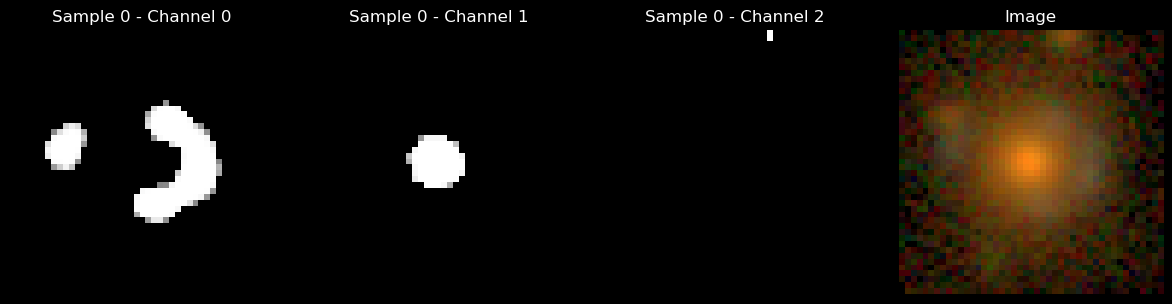

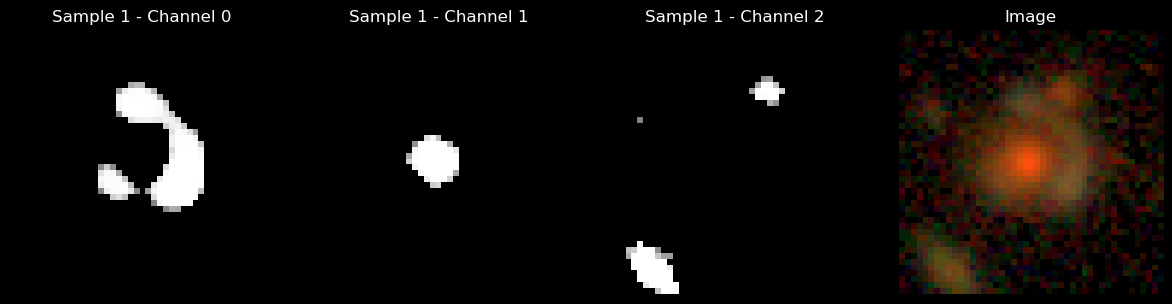

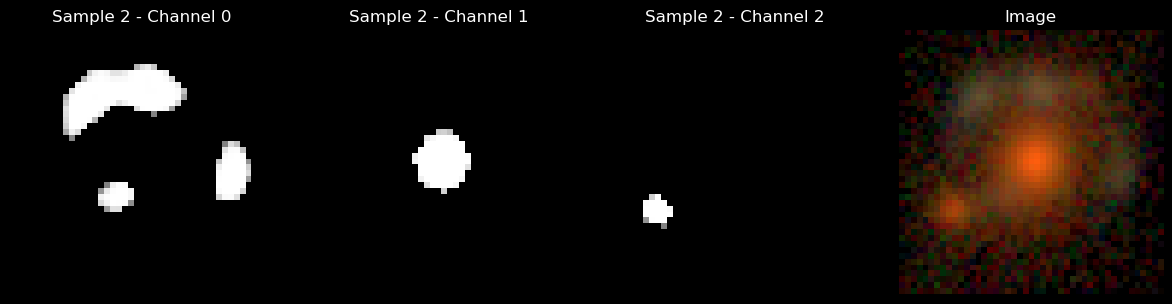

In [10]:
threshold = 0.5
for i in range(len(segmented)):
    if(i==3): break
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for c in range(3):
        channel = segmented[i][c].copy()
        channel[channel < threshold] = 0
        axes[c].imshow(channel, cmap='gray')
        axes[c].set_title(f'Sample {i} - Channel {c}')
        axes[c].axis('off')
    rgb = make_lupton_rgb(original_img[i][2], original_img[i][1], original_img[i][0], Q=11., stretch=40.)
    axes[3].set_title('Image')
    axes[3].axis('off')
    axes[3].imshow(rgb, aspect='equal')

    
    plt.tight_layout()
    plt.show()

In [11]:
def approx_theta_E(center_ra, center_dec, source_mask):
    """
    Approximate the einstein radius and error from source light
    Input: 
        * center_ra {float}: ra coordinate of center of lens in arcsec
        * center_dec {float}: dec coordinate of center of lens in arcsec
        * source_mask {2d numpy array}
    Returns: avg & stdev of distance from source to lens center in arcsec
    """
    d = []
    for i in range(0, NUM_PIX):
        for j in range (0, NUM_PIX):
            if source_mask[i][j] >= 0.5:
                # translate x, y into ra, dec
                ra = (i - (NUM_PIX)/2) * DELTA_PIX
                dec = (j - (NUM_PIX)/2) * DELTA_PIX

                sigma_ra = center_ra - ra
                sigma_dec = center_dec - dec

                dist = np.sqrt(sigma_ra ** 2 + sigma_dec ** 2)
                d.append(dist)

    return np.mean(d), np.std(d)

In [12]:
NUM_PIX = 45  # pixels per axis
DELTA_PIX = 0.2637  # pixel size in arcsec

thetaE_mean, thetaE_sigma = [], []
for i in range(len(segmented)):
    thetaE_mean_tmp, thetaE_sigma_tmp = approx_theta_E(0, 0, segmented[i][0])
    thetaE_mean.append(thetaE_mean_tmp)
    thetaE_sigma.append(thetaE_sigma_tmp)

rojas_data['pred_RE_mean'], rojas_data['pred_RE_sigma'] = thetaE_mean, thetaE_sigma

MSE: 0.22000820934772491


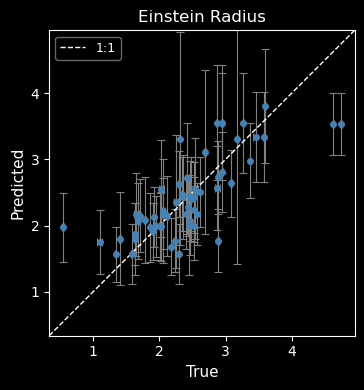

In [13]:
#MSE for Einstein radius predictions:
column = 'RE'
true_tensor = torch.tensor(rojas_data[column].values, dtype=torch.float32)
pred_tensor = torch.tensor(rojas_data['pred_RE_mean'].values, dtype=torch.float32)
mse_loss = nn.MSELoss()
mse = mse_loss(pred_tensor, true_tensor)

print(f"MSE: {mse.item()}")



fig, ax = plt.subplots(1, 1, figsize=(4, 4))

xerr = [rojas_data['L_' + column], rojas_data['U_' + column]]
yerr = rojas_data['pred_RE_sigma']
ax.errorbar(rojas_data[column], rojas_data['pred_RE_mean'], xerr=xerr, yerr=yerr, fmt='o', markersize=4, color='steelblue',
        ecolor='gray', elinewidth=0.8, capsize=3, capthick=0.8, alpha=1., linewidth=0)

# 1:1 reference line
all_vals = np.concatenate([rojas_data[column], rojas_data['pred_RE_mean']])
lims = [all_vals.min(), all_vals.max()]
margin = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - margin, lims[1] + margin]
ax.plot(lims, lims, 'w--', linewidth=1, alpha=1., label='1:1')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_title('Einstein Radius', fontsize=12)
ax.set_xlabel('True', fontsize=11)
ax.set_ylabel('Predicted', fontsize=11)
ax.tick_params(labelsize=10)
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.show()